#Regression Task

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression


#1. Exploratory Data Analysis and Data Understanding

In [65]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/nutrition_obesity.csv')
print(df.head())
print(df.info())
print(df.describe())

   YearStart  YearEnd LocationAbbr LocationDesc  \
0       2011     2011           AL      Alabama   
1       2011     2011           AL      Alabama   
2       2011     2011           AL      Alabama   
3       2011     2011           AL      Alabama   
4       2011     2011           AL      Alabama   

                                   Datasource                    Class  \
0  Behavioral Risk Factor Surveillance System  Obesity / Weight Status   
1  Behavioral Risk Factor Surveillance System  Obesity / Weight Status   
2  Behavioral Risk Factor Surveillance System  Obesity / Weight Status   
3  Behavioral Risk Factor Surveillance System  Obesity / Weight Status   
4  Behavioral Risk Factor Surveillance System  Obesity / Weight Status   

                     Topic                                           Question  \
0  Obesity / Weight Status  Percent of adults aged 18 years and older who ...   
1  Obesity / Weight Status  Percent of adults aged 18 years and older who ...   
2  Ob

In [66]:
print(df.isnull().sum())

YearStart                         0
YearEnd                           0
LocationAbbr                      0
LocationDesc                      0
Datasource                        0
Class                             0
Topic                             0
Question                          0
Data_Value_Unit               53392
Data_Value_Type                   0
Data_Value                     5046
Data_Value_Alt                 5046
Data_Value_Footnote_Symbol    48346
Data_Value_Footnote           48346
Low_Confidence_Limit           5046
High_Confidence_Limit          5046
Sample_Size                    5046
Total                         51485
Age(years)                    41954
Education                     45764
Gender                        49578
Income                        40043
Race/Ethnicity                38136
GeoLocation                    1008
ClassID                           0
TopicID                           0
QuestionID                        0
DataValueTypeID             

In [67]:
(5046/53392)*100

9.450854060533413

In [68]:
df = df.dropna(subset=['Data_Value'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48346 entries, 0 to 53386
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   YearStart                   48346 non-null  int64  
 1   YearEnd                     48346 non-null  int64  
 2   LocationAbbr                48346 non-null  object 
 3   LocationDesc                48346 non-null  object 
 4   Datasource                  48346 non-null  object 
 5   Class                       48346 non-null  object 
 6   Topic                       48346 non-null  object 
 7   Question                    48346 non-null  object 
 8   Data_Value_Unit             0 non-null      float64
 9   Data_Value_Type             48346 non-null  object 
 10  Data_Value                  48346 non-null  float64
 11  Data_Value_Alt              48346 non-null  float64
 12  Data_Value_Footnote_Symbol  0 non-null      object 
 13  Data_Value_Footnote         0 non-nu

In [69]:
df.drop(columns = ['Data_Value_Unit','Data_Value_Footnote_Symbol','Data_Value_Footnote'], inplace=True)

In [70]:
columns = df.columns
for column in columns:
  if df[column].dtype=="object":
    df[column]=df[column].fillna(df[column].mode()[0])
  else:
    df[column]=df[column].fillna(df[column].mean())

In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df = df[df['Class'] == 'Obesity / Weight Status']

In [73]:
print(df.shape)

(16254, 30)


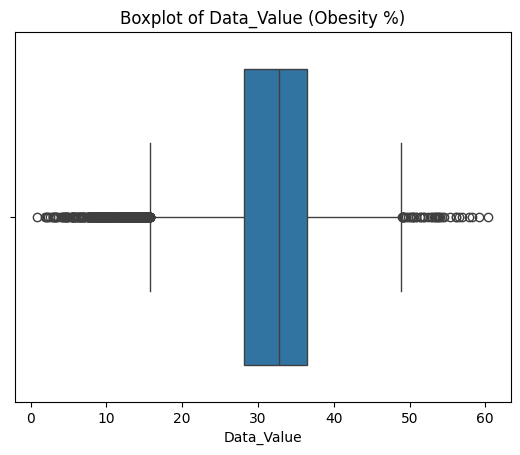

In [74]:
sns.boxplot(x=df['Data_Value'])
plt.title('Boxplot of Data_Value (Obesity %)')
plt.show()

In [75]:
df.describe()

,YearStart,YearEnd,Data_Value,Data_Value_Alt,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,LocationID
count,16254.000000,16254.000000,16254.000000,16254.000000,16254.000000,16254.000000,16254.000000,16254.000000
mean,2013.524425,2013.524425,31.927925,31.927925,27.653470,36.753008,3895.790390,30.381814
std,1.709144,1.709144,6.627183,6.627183,6.887491,7.582833,19885.389674,17.040674
min,2011.000000,2011.000000,0.900000,0.900000,0.300000,3.000000,50.000000,1.000000
25%,2012.000000,2012.000000,28.200000,28.200000,23.800000,32.200000,567.000000,17.000000
50%,2014.000000,2014.000000,32.800000,32.800000,28.500000,37.300000,1199.000000,30.000000
75%,2015.000000,2015.000000,36.500000,36.500000,32.700000,41.100000,2529.750000,44.000000
max,2016.000000,2016.000000,60.400000,60.400000,47.800000,76.300000,470700.000000,78.000000


In [76]:
print(df.groupby('StratificationCategory1')['Data_Value'].mean())

StratificationCategory1
Age (years)       31.678333
Education         32.282578
Gender            32.084297
Income            32.196518
Race/Ethnicity    31.498842
Total             32.129688
Name: Data_Value, dtype: float64


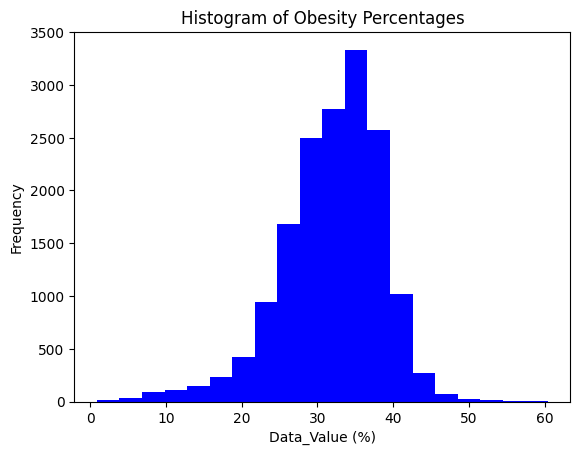

In [77]:
plt.hist(df['Data_Value'], bins=20, color='blue')
plt.title('Histogram of Obesity Percentages')
plt.xlabel('Data_Value (%)')
plt.ylabel('Frequency')
plt.show()

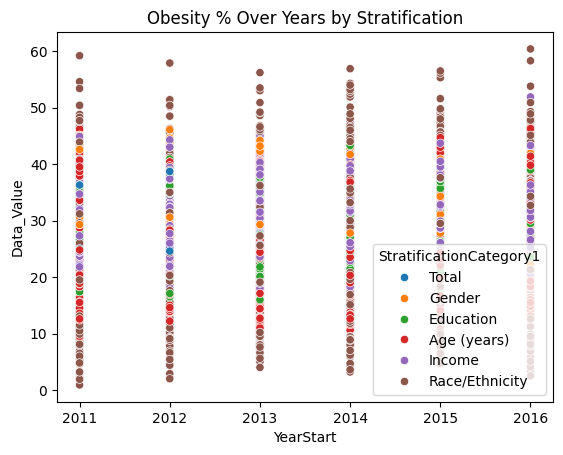

In [78]:
sns.scatterplot(x='YearStart', y='Data_Value', data=df, hue='StratificationCategory1')
plt.title('Obesity % Over Years by Stratification')
plt.show()

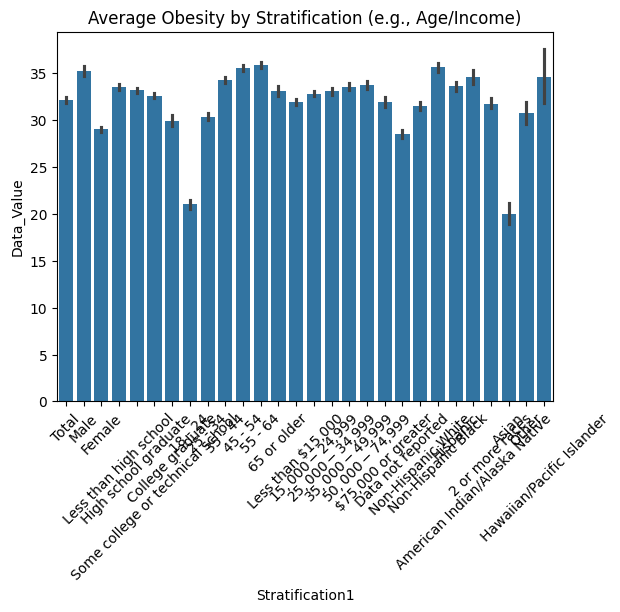

In [79]:
sns.barplot(x='Stratification1', y='Data_Value', data=df)
plt.title('Average Obesity by Stratification (e.g., Age/Income)')
plt.xticks(rotation=45)
plt.show()

#2. Build a Neural Network Model for Regression

In [80]:
features = ['YearStart', 'LocationAbbr', 'StratificationCategory1', 'Stratification1', 'Sample_Size', 'Class']
X = df[features]
y = df['Data_Value']


numeric_features = ['YearStart', 'Sample_Size']
categorical_features = ['LocationAbbr', 'StratificationCategory1', 'Stratification1', 'Class']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:

mlp = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42
    ))
])

mlp.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['YearStart', 'Sample_Size']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['LocationAbbr',
                                                   'StratificationCategory1',
                                                   'Stratification1',
                                                   'Class'])])),
                ('regressor',
                 MLPRegressor(hidden_layer_sizes=(100, 50), random_state=42))])

In [82]:
y_pred = mlp.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

MSE: 34.60, RMSE: 5.88, MAE: 4.69, R2: 0.21


#3. Build Primary Machine Learning Models

#Model 1: Linear Regression

In [83]:
lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression: MSE {mse_lr:.2f}, RMSE {rmse_lr:.2f}, MAE {mae_lr:.2f}, R2 {r2_lr:.2f}")

Linear Regression: MSE 29.27, RMSE 5.41, MAE 4.30, R2 0.33


#Model 1: K-Nearest Neighbors Regressor

In [84]:

from sklearn.neighbors import KNeighborsRegressor
knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=5))
])


knn.fit(X_train, y_train)


y_pred_knn = knn.predict(X_test)

mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print(f"KNN: MSE {mse_knn:.2f}, RMSE {rmse_knn:.2f}, MAE {mae_knn:.2f}, R2 {r2_knn:.2f}")

KNN: MSE 38.86, RMSE 6.23, MAE 4.93, R2 0.12


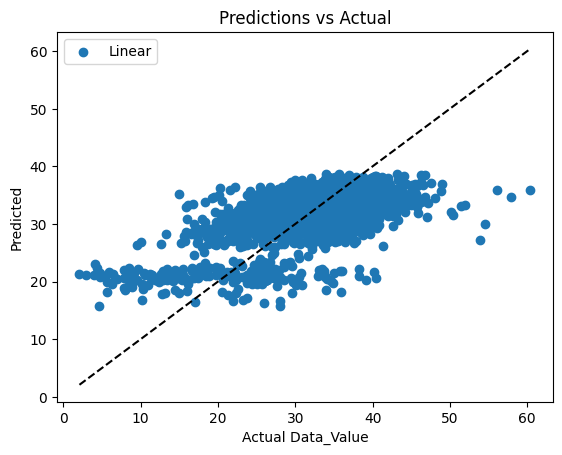

In [85]:
plt.scatter(y_test, y_pred_lr, label='Linear')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual Data_Value')
plt.ylabel('Predicted')
plt.legend()
plt.title('Predictions vs Actual')
plt.show()

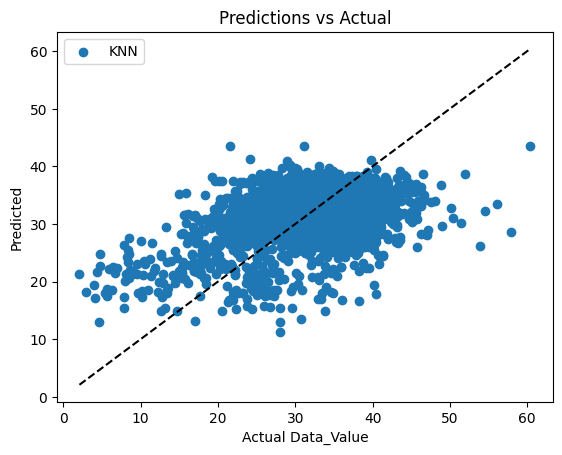

In [86]:
plt.scatter(y_test, y_pred_knn, label='KNN')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual Data_Value')
plt.ylabel('Predicted')
plt.legend()
plt.title('Predictions vs Actual')
plt.show()

#4. Hyperparameter Optimization with Cross-Validation

In [87]:


param_grid_lr = {
    'regressor__fit_intercept': [True, False]
}

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,
    scoring='neg_mean_squared_error'
)


grid_lr.fit(X_train, y_train)


print("Best Params for Linear:", grid_lr.best_params_)
best_mse_lr = -grid_lr.best_score_
print(f"Best CV MSE for Linear: {best_mse_lr:.2f}")

Best Params for Linear: {'regressor__fit_intercept': False}
Best CV MSE for Linear: 29.92


In [88]:
param_grid_knn = {
    'regressor__n_neighbors': [3, 5, 7],
}

grid_knn = GridSearchCV(
    knn,
    param_grid_knn,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid_knn.fit(X_train, y_train)

print("Best Params for KNN:", grid_knn.best_params_)
best_mse_knn = -grid_knn.best_score_
print(f"Best CV MSE for KNN: {best_mse_knn:.2f}")

Best Params for KNN: {'regressor__n_neighbors': 7}
Best CV MSE for KNN: 35.67


#5. Feature Selection

In [89]:
X_train_pre = preprocessor.fit_transform(X_train)


selector = SelectKBest(score_func=f_regression, k=5)

selector.fit(X_train_pre, y_train)


selected_mask = selector.get_support()
scores = selector.scores_
print("Feature Scores:", scores)


feature_names = preprocessor.get_feature_names_out()
selected_features = feature_names[selected_mask]
print("Selected Features:", selected_features)

Feature Scores: [3.08939963e+01 4.29939201e-01 8.73086216e-01 1.94890326e+01
 2.95204927e+01 8.38974340e-01 2.17295988e+01 8.13649833e+01
 7.57196333e+00 1.40751162e+02 3.15229641e+00 5.74082401e+00
 5.18574447e-01 7.90943298e-01 5.19758407e+01 1.85750585e+00
 3.95815061e-01 1.96405855e-01 7.06281205e+00 5.40469307e+00
 1.38045480e+01 3.02131683e+01 4.69616125e+01 4.55478641e-04
 5.93952077e-01 3.00944198e+00 4.83123654e-01 2.99137242e+00
 3.41614959e+01 4.13424670e+00 4.27172374e+00 9.75312888e+00
 6.79410401e+00 8.35457958e+00 4.02919464e+00 2.28625630e-02
 1.99624532e+00 2.05572642e+01 4.54653836e+00 1.57446777e+01
 5.24824311e+00 2.48078106e-01 2.60458344e+00 1.27006417e+00
 5.84598226e+00 3.13974785e+00 1.69176172e+01 7.52143134e+00
 4.52529546e-02 3.60048856e+01 9.57903314e-02 2.08828763e+00
 8.78796239e+00 2.84245575e+00 5.98802270e+00 3.03360122e+01
 3.96516323e-01 1.06388974e+01 7.47903643e+00 1.80952616e-01
 9.46921806e+00 1.02464363e+01 1.07418094e+00 9.42318421e+00
 1.96444

#6. Final Models and Comparative Analysis

In [90]:
selected_features_original = [
    'YearStart',
    'Sample_Size',
    'LocationAbbr',
    'StratificationCategory1',
    'Stratification1',
    'Class'
]

print("Using these original columns:", selected_features_original)


selected_numeric = ['YearStart', 'Sample_Size']
selected_categorical = ['LocationAbbr', 'StratificationCategory1', 'Stratification1']

new_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), selected_numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), selected_categorical)
    ])


X_selected = df[selected_features_original].copy()
y = df['Data_Value']


X_train_sel, X_test_sel, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)


final_lr = Pipeline(steps=[
    ('preprocessor', new_preprocessor),
    ('regressor', LinearRegression(
        fit_intercept=grid_lr.best_params_['regressor__fit_intercept']
    ))
])

final_lr.fit(X_train_sel, y_train)

final_knn = Pipeline(steps=[
    ('preprocessor', new_preprocessor),
    ('regressor', KNeighborsRegressor(
        n_neighbors=grid_knn.best_params_['regressor__n_neighbors']

    ))
])


final_knn.fit(X_train_sel, y_train)

Using these original columns: ['YearStart', 'Sample_Size', 'LocationAbbr', 'StratificationCategory1', 'Stratification1', 'Class']


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['YearStart', 'Sample_Size']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['LocationAbbr',
                                                   'StratificationCategory1',
                                                   'Stratification1'])])),
                ('regressor', KNeighborsRegressor(n_neighbors=7))])

In [91]:
# Predict for final Linear
y_pred_final_lr = final_lr.predict(X_test_sel)

# Metrics (same as before)
mse_final_lr = mean_squared_error(y_test, y_pred_final_lr)
rmse_final_lr = np.sqrt(mse_final_lr)
mae_final_lr = mean_absolute_error(y_test, y_pred_final_lr)
r2_final_lr = r2_score(y_test, y_pred_final_lr)
print(f"Final Linear: MSE {mse_final_lr:.2f}, RMSE {rmse_final_lr:.2f}, MAE {mae_final_lr:.2f}, R2 {r2_final_lr:.2f}")

# Same for KNN
y_pred_final_knn = final_knn.predict(X_test_sel)
mse_final_knn = mean_squared_error(y_test, y_pred_final_knn)
rmse_final_knn = np.sqrt(mse_final_knn)
mae_final_knn = mean_absolute_error(y_test, y_pred_final_knn)
r2_final_knn = r2_score(y_test, y_pred_final_knn)
print(f"Final KNN: MSE {mse_final_knn:.2f}, RMSE {rmse_final_knn:.2f}, MAE {mae_final_knn:.2f}, R2 {r2_final_knn:.2f}")

Final Linear: MSE 29.27, RMSE 5.41, MAE 4.30, R2 0.33
Final KNN: MSE 35.86, RMSE 5.99, MAE 4.75, R2 0.18


In [92]:

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN Regressor'],
    'Selected Features Count': [len(selected_features), len(selected_features)],
    'Best Hyperparameters': [str(grid_lr.best_params_), str(grid_knn.best_params_)],
    'Test RMSE': [rmse_final_lr, rmse_final_knn],
    'Test R2': [r2_final_lr, r2_final_knn],
    'Improvement from Original': [rmse_lr - rmse_final_lr, rmse_knn - rmse_final_knn]
})

comparison.to_csv('/content/drive/MyDrive/Colab Notebooks/comparison.csv', index=False)


In [93]:
df_comparison=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/comparison.csv')
print(df_comparison.to_markdown(index=False))

| Model             |   Selected Features Count | Best Hyperparameters                |   Test RMSE |   Test R2 |   Improvement from Original |
|:------------------|--------------------------:|:------------------------------------|------------:|----------:|----------------------------:|
| Linear Regression |                         5 | {'regressor__fit_intercept': False} |     5.41003 |  0.334752 |                 1.15054e-06 |
| KNN Regressor     |                         5 | {'regressor__n_neighbors': 7}       |     5.98847 |  0.184889 |                 0.245242    |
